In [205]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim

import yfinance as yf

from sklearn.metrics import mean_squared_error

In [206]:
ticker = 'AAPL'
df = yf.download(ticker, start='2020-01-01', end='2025-01-01')


[*********************100%***********************]  1 of 1 completed


In [207]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200


In [208]:
df.shape

(1258, 5)

Text(0.5, 1.0, 'Stock Price Over Time')

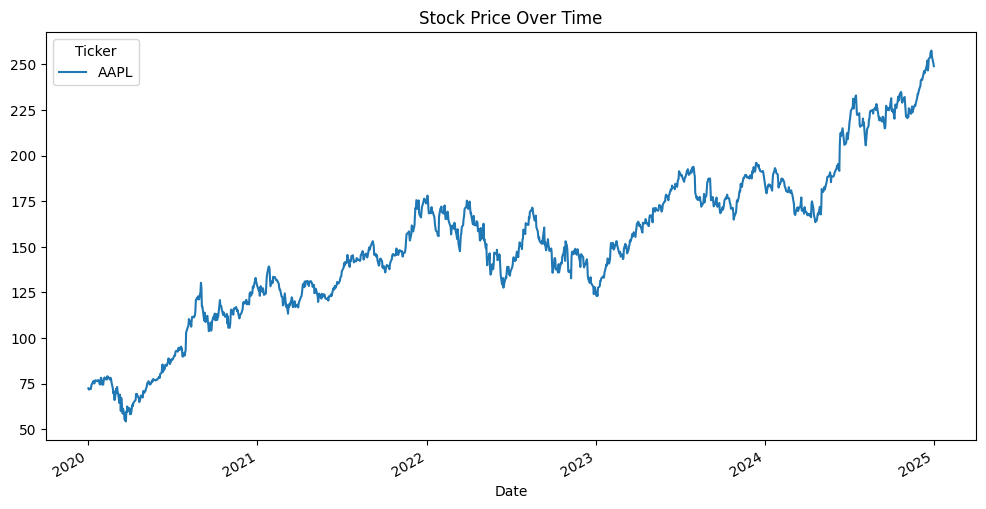

In [209]:
df['Close'].plot(figsize=(12, 6))
plt.title('Stock Price Over Time')

In [210]:
scalar = StandardScaler()
df['Close'] = scalar.fit_transform(df['Close'])

In [211]:
df['Close'].sample(4)

Ticker,AAPL
Date,
2024-10-30,1.840791
2022-03-01,0.200210
2023-12-20,0.986523
2024-09-20,1.795712


In [212]:
seq_length = 30
data = []
for i in range(len(df) - seq_length):
    data.append(df['Close'].values[i:i+seq_length])
data = np.array(data)


In [213]:
train_data = int(len(data) * 0.8)
# data[:train_data, :-1, :] -> samples, time steps, features
X_train = torch.from_numpy(data[:train_data, :-1, :]).float()
y_train = torch.from_numpy(data[:train_data, -1, :]).float()
X_test = torch.from_numpy(data[train_data:, :-1, :]).float()
y_test = torch.from_numpy(data[train_data:, -1, :]).float()

In [214]:
class StockPriceLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.4)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out    

In [215]:
model = StockPriceLSTM(input_size=1, hidden_size=30, num_layers=2, output_size=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 100

In [216]:
for epoch in range(num_epochs):
    
    y_train_pred = model(X_train)
    loss = criterion(y_train_pred, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.5722
Epoch [20/100], Loss: 0.4525
Epoch [30/100], Loss: 0.2557
Epoch [40/100], Loss: 0.0752
Epoch [50/100], Loss: 0.0699
Epoch [60/100], Loss: 0.0430
Epoch [70/100], Loss: 0.0342
Epoch [80/100], Loss: 0.0254
Epoch [90/100], Loss: 0.0221
Epoch [100/100], Loss: 0.0186


In [217]:
model.eval()
y_test_pred = model(X_test).detach().numpy()

y_train_pred = scalar.inverse_transform(y_train_pred.detach().numpy())
y_train = scalar.inverse_transform(y_train.detach().numpy())
y_test_pred = scalar.inverse_transform(y_test_pred)
y_test = scalar.inverse_transform(y_test.detach().numpy())

In [218]:
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

In [219]:
train_rmse

5.7176676

In [220]:
test_rmse

21.911346

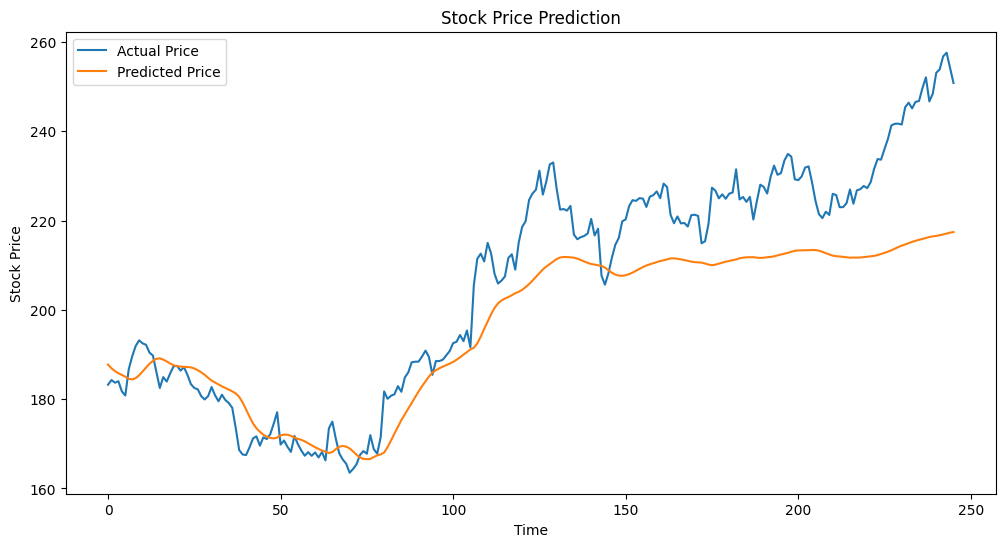

In [223]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Price')
plt.plot(predicted, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.title('Stock Price Prediction')
plt.legend()
plt.show()